# Аудит выбранной архитектуры Юрия

Этот ноутбук не выбирает новую модель и не меняет policy. Он независимо проверяет уже выбранную командой архитектуру `pooled base engines → threshold selector → cooldown 2 дня → максимум 2 сообщения за 7 дней`.

Проверки:

1. воспроизводимость временной схемы и итоговые holdout-метрики;
2. 95% доверительные интервалы lift и BPS uplift с помощью четырёхнедельного block bootstrap;
3. rolling-origin OOT на 2024, 2025 и неполном 2026 году;
4. доля календарных недель без сообщений и максимальная непрерывная пауза по каждой валюте.

Запускайте через **Restart Kernel → Run All**. Первая тяжёлая ячейка выполняет полный causal walk-forward и может занимать несколько минут.

In [1]:
from dataclasses import replace
from datetime import date
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

candidate_roots = (Path.cwd().resolve(), *Path.cwd().resolve().parents)
PROJECT_ROOT = next((
    root for root in candidate_roots
    if (root / 'src' / 'cbr_loader.py').is_file()
), None)
if PROJECT_ROOT is None:
    raise RuntimeError('Не найден корень репозитория с папкой src')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.cbr_loader import (
    CURRENCIES, load_cbr_history, parse_history_records,
)
from src.features import build_features
from src.market_data import build_daily_market_panel
from src.outcomes import add_future_outcomes
from src.signal_backtest import (
    backtest_signal_stream, build_evaluation_universe,
)
from research.yura.src.config import YuraPipelineConfig
from research.yura.src.pipeline import run_yura_pipeline
from research.yura.src.policy import apply_signal_policy
from research.yura.src.selector import (
    ThresholdSelector, build_opportunity_selector,
)
from research.yura.src.targets import build_yura_targets

AUDIT_START_DATE = date(2018, 1, 1)
AUDIT_END_DATE = date(2026, 9, 5)
RAW_DIR = PROJECT_ROOT / 'data' / 'raw' / 'cbr'
OUTPUT_DIR = (
    PROJECT_ROOT / 'research' / 'aleksandr' / 'outputs' / 'yura_audit'
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = YuraPipelineConfig(
    ml_scope='pooled', holdout_start='2025-01-01'
)
SELECTOR = build_opportunity_selector('threshold')
print(f'Корень проекта: {PROJECT_ROOT}')
CONFIG

Корень проекта: /Users/aleksandr/PycharmProjects/huck/AI_Product_Hack_trigger_model


YuraPipelineConfig(currencies=('AMD', 'KZT', 'KGS', 'TJS', 'UZS'), target_families=('G0', 'W1'), horizons=(1, 3, 5, 10, 20), base_oos_start=None, arbiter_validation_start=None, holdout_start='2025-01-01', train_months=36, retrain_months=6, rule_confidence_months=24, rule_confidence_prior_strength=20.0, confidence_warmup_months=12, selector_validation_months=36, relative_rank_months=36, w1_deterioration_bps=75.0, w1_low_percentile=0.15, rule_min_signals_per_week=0.25, rule_max_signals_per_week=4.0, ml_learning_rate=0.06, ml_max_iter=80, ml_max_leaf_nodes=7, ml_min_samples_leaf=30, ml_l2_regularization=2.0, ml_scope='pooled', random_state=42, rule_lift_thresholds=(1.3,), ml_lift_thresholds=(1.3,), min_expected_bps_options=(0.0,), decision_score_thresholds=(0.0,), cooldown_options=(2,), max_signals_per_7d=2, min_average_signals_per_week=1.0, max_average_signals_per_week=2.0, validation_quarterly_lift_floor=1.3, learned_selector_calibration_months=12, learned_selector_validation_months=12,

## 1. Данные и запуск выбранной архитектуры

Дата окончания зафиксирована на 5 сентября 2026 года, чтобы повторный запуск давал тот же временной срез. Сначала ноутбук запрашивает официальный XML ЦБ. Если сеть недоступна, он использует XML того же диапазона из локального `data/raw/cbr`.

Future outcomes применяются только как исторические labels. В признаки ML они не входят. Встроенный temporal audit проверяет, что каждый label созрел до даты обучения.

In [2]:
def load_audit_history():
    try:
        return load_cbr_history(
            start_date=AUDIT_START_DATE, end_date=AUDIT_END_DATE,
            currencies=CURRENCIES, raw_dir=RAW_DIR,
        )
    except RuntimeError as network_error:
        frames = []
        for currency in CURRENCIES:
            snapshot = RAW_DIR / (
                f'{currency}_{AUDIT_START_DATE:%Y%m%d}_'
                f'{AUDIT_END_DATE:%Y%m%d}.xml'
            )
            if not snapshot.is_file():
                raise RuntimeError(
                    f'ЦБ недоступен и нет локального снимка {snapshot}'
                ) from network_error
            records = parse_history_records(snapshot.read_bytes(), currency)
            records['available_at'] = (
                records['effective_date'] + pd.Timedelta(days=1)
            )
            frames.append(records)
        print('ЦБ недоступен: использован фиксированный локальный XML-снимок')
        return pd.concat(frames, ignore_index=True)

cbr_history = load_audit_history()
rates = (
    cbr_history.pivot(
        index='available_at', columns='currency', values='normalized_rate'
    ).reindex(columns=list(CURRENCIES)).sort_index()
)
rates.columns.name = None
market_panel = build_daily_market_panel(rates)
features = build_features(market_panel)
outcomes = add_future_outcomes(features, horizons=CONFIG.horizons)
dataset, target_registry = build_yura_targets(
    outcomes, horizons=CONFIG.horizons,
    w1_deterioration_bps=CONFIG.w1_deterioration_bps,
    w1_low_percentile=CONFIG.w1_low_percentile,
)
scoring_data = dataset.loc[
    dataset['is_update_day']
    & dataset['currency'].isin(CONFIG.currencies)
].copy()

result = run_yura_pipeline(
    scoring_data, target_registry=target_registry,
    config=CONFIG, selector=SELECTOR,
)
display(result.temporal_plan.as_frame())
display(result.action_summary.round(3))
display(result.backtest_summary.loc[
    result.backtest_summary['scope'].eq('currency')
].round(3))
print(f'Base candidates: {len(result.base_replay.candidates):,}')
print(f'Финальных holdout-сигналов: {len(result.final_signals):,}')

,data_start,data_end,base_oos_start,selector_validation_start,selector_validation_end,holdout_start,maximum_horizon_days
0,2018-01-01,2026-09-06,2021-01-01,2022-01-01,2025-01-01,2025-01-01,20


,currency,signal_count,calendar_weeks,signals_per_week,mean_benefit_bps,random_mean_benefit_bps,benefit_uplift_bps,positive_benefit_rate
0,AMD,117,86.143,1.358,43.424,2.127,41.297,0.718
1,KGS,120,86.143,1.393,29.043,2.534,26.509,0.658
2,KZT,120,86.143,1.393,46.802,6.303,40.499,0.725
3,TJS,108,86.143,1.254,41.756,1.956,39.800,0.722
4,UZS,110,86.143,1.277,40.792,2.566,38.226,0.718


,scope,currency,horizon,target_family,observations,positive_count,signal_count,true_positive,false_positive,precision,random_precision,lift,calendar_weeks,signals_per_week,mean_benefit_bps,random_mean_benefit_bps,benefit_uplift_bps,positive_benefit_rate
0,currency,AMD,ALL,ALL,4056,425,117,31,86,0.265,0.097,2.721,86.143,1.358,43.424,2.127,41.297,0.718
1,currency,KGS,ALL,ALL,4056,416,120,28,92,0.233,0.103,2.275,86.143,1.393,29.043,2.534,26.509,0.658
2,currency,KZT,ALL,ALL,4056,426,120,25,95,0.208,0.104,1.998,86.143,1.393,46.802,6.303,40.499,0.725
3,currency,TJS,ALL,ALL,4056,399,108,31,77,0.287,0.113,2.533,86.143,1.254,41.756,1.956,39.800,0.722
4,currency,UZS,ALL,ALL,4056,435,110,28,82,0.255,0.123,2.072,86.143,1.277,40.792,2.566,38.226,0.718


Base candidates: 244,933
Финальных holdout-сигналов: 575


## 2. Блочный bootstrap

Обычный bootstrap отдельных сигналов считал бы соседние даты независимыми и давал бы слишком оптимистичный интервал. Здесь целиком пересэмплируются последовательные блоки по четыре календарные недели.

Lift сравнивает фактические попадания с ожидаемыми попаданиями случайного дня того же состава `currency × target × horizon`. `mean_bps_uplift` — фактическая выгода минус средняя выгода того же случайного состава. Bootstrap ничего не переобучает и не выбирает.

,currency,signals,lift,lift_ci_low,lift_ci_high,p_lift_gt_1p3,mean_bps_uplift,bps_ci_low,bps_ci_high,p_bps_uplift_gt_0
0,ALL,575,2.307,1.906,2.781,1.000,37.175,23.232,50.886,1.000
1,AMD,117,2.721,2.014,3.501,1.000,41.297,27.719,55.776,1.000
2,KGS,120,2.275,1.594,3.004,0.999,26.509,9.741,43.094,0.999
3,KZT,120,1.998,1.381,2.656,0.988,40.499,25.337,56.927,1.000
4,TJS,108,2.533,1.897,3.171,1.000,39.800,22.268,55.543,1.000
5,UZS,110,2.072,1.513,2.723,0.998,38.226,17.227,59.069,1.000


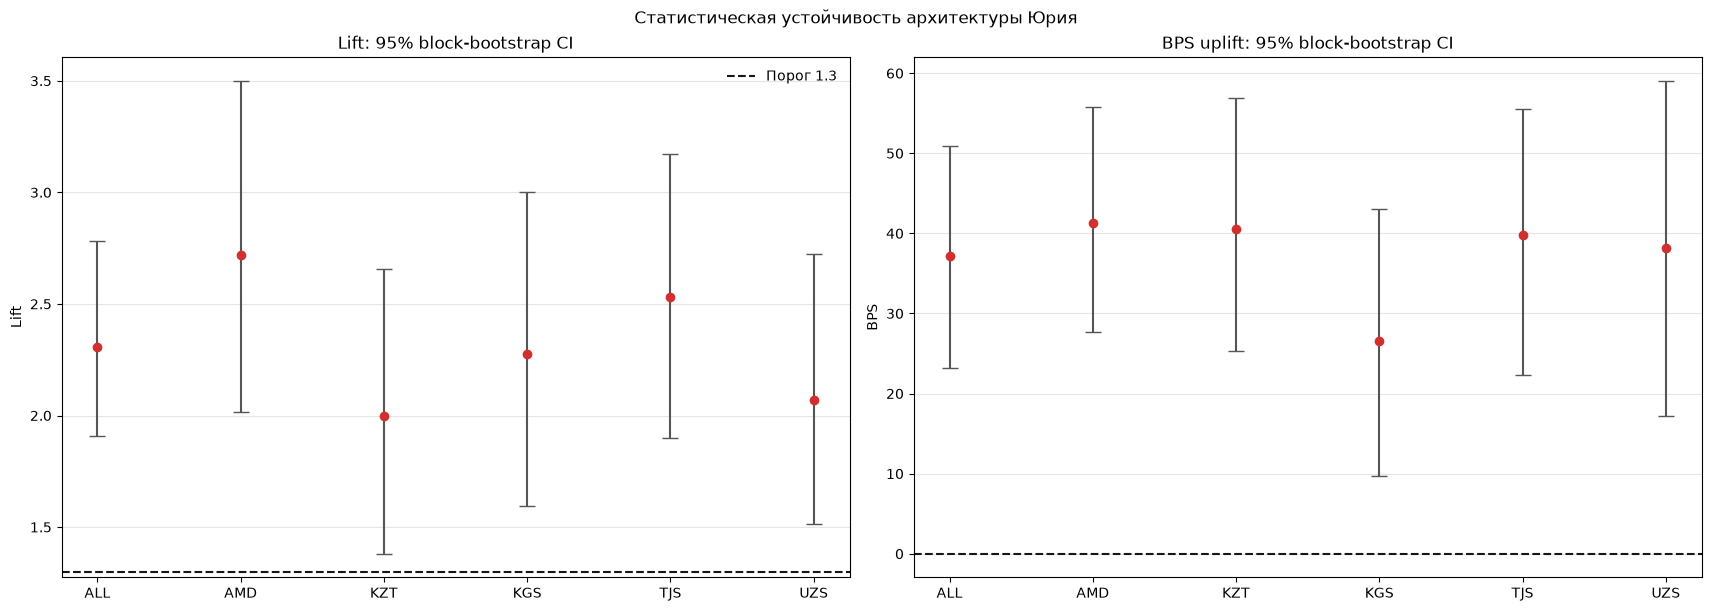

In [3]:
BOOTSTRAP_REPEATS = 2000
BOOTSTRAP_BLOCK_WEEKS = 4
BOOTSTRAP_SEED = 42

def block_bootstrap(backtest_rows, repeats=2000, block_weeks=4, seed=42):
    rows = backtest_rows.copy()
    rows['available_at'] = pd.to_datetime(rows['available_at'])
    rows['week'] = rows['available_at'].dt.to_period('W-SUN').dt.start_time
    signal = rows['signal'].astype(bool)
    rows['_signal'] = signal.astype(int)
    rows['_tp'] = (signal & rows['target_value'].astype(bool)).astype(int)
    rows['_expected_tp'] = rows['_signal'] * pd.to_numeric(
        rows['_stratum_random_precision'], errors='coerce'
    )
    benefit_delta = (
        pd.to_numeric(rows['benefit_bps'], errors='coerce')
        - pd.to_numeric(
            rows['_stratum_random_benefit_bps'], errors='coerce'
        )
    )
    valid_benefit = signal & benefit_delta.notna()
    rows['_bps_sum'] = np.where(valid_benefit, benefit_delta, 0.0)
    rows['_bps_count'] = valid_benefit.astype(int)
    columns = [
        '_signal', '_tp', '_expected_tp', '_bps_sum', '_bps_count'
    ]
    weeks = pd.date_range(rows['week'].min(), rows['week'].max(), freq='W-MON')
    by_currency = rows.groupby(
        ['currency', 'week'], as_index=False
    )[columns].sum()
    overall = (
        rows.groupby('week', as_index=False)[columns].sum()
        .assign(currency='ALL')
    )
    weekly = pd.concat([by_currency, overall], ignore_index=True)

    rng = np.random.default_rng(seed)
    week_count = len(weeks)
    block_count = int(np.ceil(week_count / block_weeks))
    weights = np.zeros((repeats, week_count), dtype=int)
    for repeat in range(repeats):
        starts = rng.integers(0, week_count, size=block_count)
        positions = np.concatenate([
            (np.arange(start, start + block_weeks) % week_count)
            for start in starts
        ])[:week_count]
        weights[repeat] = np.bincount(positions, minlength=week_count)

    output = []
    for currency, sample in weekly.groupby('currency', sort=True):
        matrix = (
            sample.set_index('week')[columns]
            .reindex(weeks, fill_value=0).to_numpy(float)
        )
        sampled = weights @ matrix
        signals, tp, expected_tp, bps_sum, bps_count = sampled.T
        lift = np.divide(
            tp, expected_tp, out=np.full(repeats, np.nan),
            where=expected_tp > 0,
        )
        bps = np.divide(
            bps_sum, bps_count, out=np.full(repeats, np.nan),
            where=bps_count > 0,
        )
        point = matrix.sum(axis=0)
        output.append({
            'currency': currency, 'signals': int(point[0]),
            'lift': point[1] / point[2],
            'lift_ci_low': float(np.nanquantile(lift, 0.025)),
            'lift_ci_high': float(np.nanquantile(lift, 0.975)),
            'p_lift_gt_1p3': float(np.nanmean(lift > 1.3)),
            'mean_bps_uplift': point[3] / point[4],
            'bps_ci_low': float(np.nanquantile(bps, 0.025)),
            'bps_ci_high': float(np.nanquantile(bps, 0.975)),
            'p_bps_uplift_gt_0': float(np.nanmean(bps > 0)),
        })
    return pd.DataFrame(output)

bootstrap_summary = block_bootstrap(
    result.backtest_rows, repeats=BOOTSTRAP_REPEATS,
    block_weeks=BOOTSTRAP_BLOCK_WEEKS, seed=BOOTSTRAP_SEED,
)
bootstrap_summary.to_csv(OUTPUT_DIR / 'bootstrap.csv', index=False)
display(bootstrap_summary.round(3))

plot_data = bootstrap_summary.set_index('currency').reindex(
    ['ALL', *CONFIG.currencies]
)
positions = np.arange(len(plot_data))
fig, axes = plt.subplots(1, 2, figsize=(17, 6), constrained_layout=True)
axes[0].errorbar(
    positions, plot_data['lift'],
    yerr=np.vstack([
        plot_data['lift'] - plot_data['lift_ci_low'],
        plot_data['lift_ci_high'] - plot_data['lift'],
    ]), fmt='o', capsize=6, color='#d32f2f', ecolor='#555555',
)
axes[0].axhline(1.3, color='#161616', linestyle='--', label='Порог 1.3')
axes[0].set(title='Lift: 95% block-bootstrap CI', ylabel='Lift')
axes[0].legend(frameon=False)
axes[1].errorbar(
    positions, plot_data['mean_bps_uplift'],
    yerr=np.vstack([
        plot_data['mean_bps_uplift'] - plot_data['bps_ci_low'],
        plot_data['bps_ci_high'] - plot_data['mean_bps_uplift'],
    ]), fmt='o', capsize=6, color='#d32f2f', ecolor='#555555',
)
axes[1].axhline(0, color='#161616', linestyle='--')
axes[1].set(title='BPS uplift: 95% block-bootstrap CI', ylabel='BPS')
for ax in axes:
    ax.set_xticks(positions, plot_data.index)
    ax.grid(axis='y', color='#e5e5e5')
fig.suptitle('Статистическая устойчивость архитектуры Юрия')
fig.savefig(OUTPUT_DIR / 'bootstrap_intervals.png', dpi=180)
plt.show()

## 3. Rolling-origin OOT

Перед каждым тестовым окном selector проходит validation только на прошлом. Base engines уже сформировали causal walk-forward predictions и не заглядывают вперёд. В конце каждого окна применяется purge: событие попадает в качество только тогда, когда его `available_at + horizon` находится внутри окна.

`emitted_signals` — реально выпущенные сообщения. `evaluated_signals` — их подмножество с уже созревшим target. Такое разделение особенно важно для неполного 2026 года.

/var/folders/8j/p_s0cg9s1gld5sntq73tvjx80000gn/T/ipykernel_4080/965077409.py:99: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(oot_summary.round(3))


,oot_period,validation_end,oot_start,oot_end_exclusive,complete_year,emitted_signals,evaluated_signals,pooled_lift,macro_currency_lift,min_currency_lift,mean_bps_uplift,positive_bps_uplift_rate,mean_emitted_signals_per_week,all_currencies_lift_ge_1p3,leakage_free
0,2024,2024-01-01,2024-01-01,2025-01-01,True,323,308,2.618,2.635,2.235,57.082,0.760,1.236,True,True
1,2025,2025-01-01,2025-01-01,2026-01-01,True,393,385,1.836,1.861,1.474,32.565,0.655,1.507,True,True
2,2026 (partial),2026-01-01,2026-01-01,2026-09-07,False,182,182,3.557,3.643,2.651,45.193,0.769,1.023,True,True


oot_period,2024,2025,2026 (partial)
currency,,,
AMD,2.671,2.104,4.774
KGS,2.915,1.571,3.749
KZT,2.674,1.474,3.510
TJS,2.681,2.475,2.651
UZS,2.235,1.681,3.532


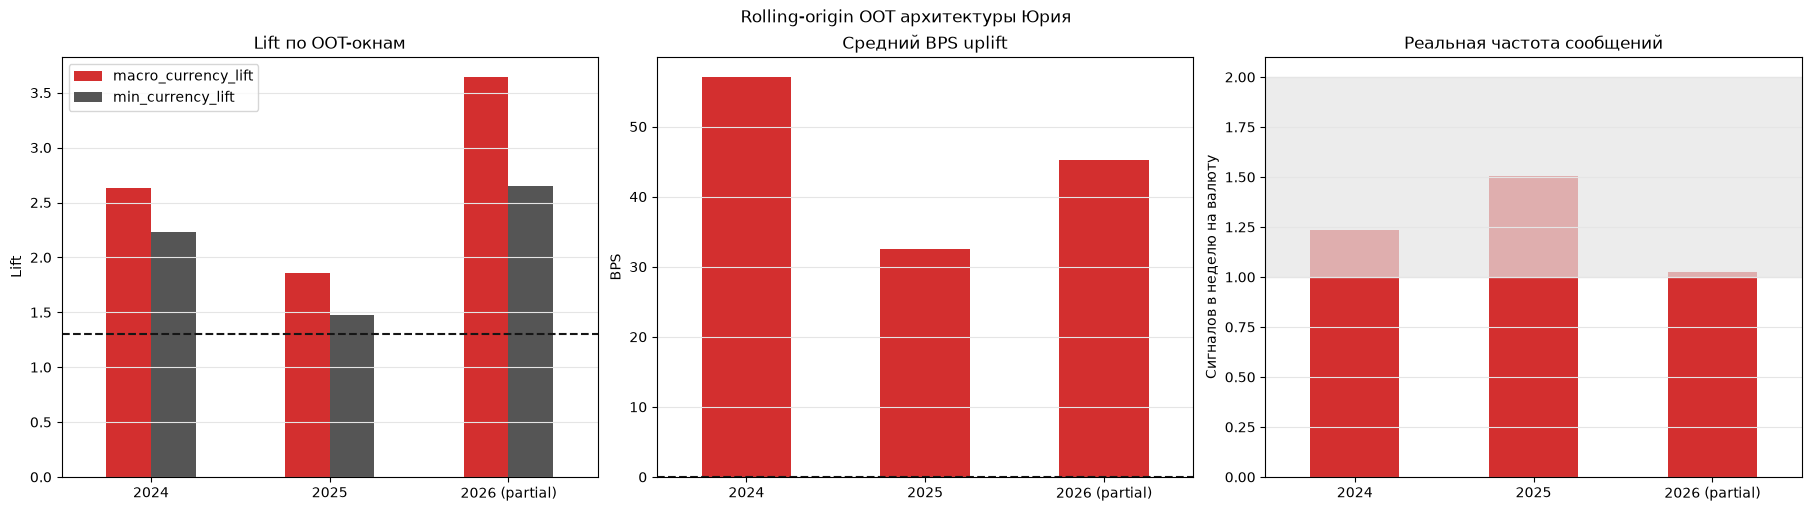

In [4]:
selected_registry = target_registry.loc[
    target_registry['family'].isin(CONFIG.target_families)
    & target_registry['horizon'].isin(CONFIG.horizons)
].copy()
full_universe = build_evaluation_universe(
    scoring_data, target_registry=selected_registry,
    target_families=CONFIG.target_families,
    currencies=CONFIG.currencies,
    start_date=result.temporal_plan.base_oos_start,
)
candidates = result.action_candidates.copy()
candidate_dates = pd.to_datetime(candidates['available_at'])
universe_dates = pd.to_datetime(full_universe['available_at'])
universe_maturity = universe_dates + pd.to_timedelta(
    full_universe['horizon'], unit='D'
)
observed_end = pd.Timestamp(result.temporal_plan.data_end).normalize()

oot_rows = []
oot_currency_parts = []
for start_value in ('2024-01-01', '2025-01-01', '2026-01-01'):
    start = pd.Timestamp(start_value)
    nominal_end = start + pd.DateOffset(years=1)
    end = min(nominal_end, observed_end + pd.Timedelta(days=1))
    fold_config = replace(result.config, holdout_start=start.isoformat())
    selector = ThresholdSelector()
    fitted, _ = selector.fit(
        candidates, evaluation_universe=full_universe, config=fold_config
    )
    fold_candidates = candidates.loc[
        candidate_dates.ge(start) & candidate_dates.lt(end)
    ].copy()
    selected = selector.select(fold_candidates, fitted)
    emitted_events = apply_signal_policy(
        selected, selector.policy_config(fitted)
    )
    fold_universe = full_universe.loc[
        universe_dates.ge(start) & universe_dates.lt(end)
        & universe_maturity.lt(end)
    ].copy()
    fold_summary, fold_scored = backtest_signal_stream(
        emitted_events, evaluation_universe=fold_universe
    )
    currency = fold_summary.loc[
        fold_summary['scope'].eq('currency')
    ].copy()
    evaluated = int(currency['signal_count'].sum())
    expected_tp = float(
        (currency['signal_count'] * currency['random_precision']).sum()
    )
    true_positive = int(currency['true_positive'].sum())
    signal_rows = fold_scored.loc[fold_scored['signal']]
    bps_delta = (
        pd.to_numeric(signal_rows['benefit_bps'], errors='coerce')
        - pd.to_numeric(
            signal_rows['_stratum_random_benefit_bps'], errors='coerce'
        )
    )
    period_weeks = (end - start).days / 7
    emitted_by_currency = (
        emitted_events.groupby('currency').size()
        .reindex(CONFIG.currencies, fill_value=0)
    )
    label = str(start.year) + (' (partial)' if end < nominal_end else '')
    oot_rows.append({
        'oot_period': label, 'validation_end': fitted.validation_end,
        'oot_start': start, 'oot_end_exclusive': end,
        'complete_year': bool(end == nominal_end),
        'emitted_signals': int(len(emitted_events)),
        'evaluated_signals': evaluated,
        'pooled_lift': true_positive / expected_tp,
        'macro_currency_lift': float(currency['lift'].mean()),
        'min_currency_lift': float(currency['lift'].min()),
        'mean_bps_uplift': float(bps_delta.mean()),
        'positive_bps_uplift_rate': float(bps_delta.gt(0).mean()),
        'mean_emitted_signals_per_week': float(
            emitted_by_currency.mean() / period_weeks
        ),
        'all_currencies_lift_ge_1p3': bool(
            currency['lift'].ge(1.3).all()
        ),
        'leakage_free': bool(pd.Timestamp(fitted.validation_end) == start),
    })
    detail = currency[[
        'currency', 'signal_count', 'lift', 'benefit_uplift_bps'
    ]].rename(columns={'signal_count': 'evaluated_signals'})
    detail['emitted_signals'] = detail['currency'].map(emitted_by_currency)
    detail['emitted_signals_per_week'] = (
        detail['emitted_signals'] / period_weeks
    )
    detail.insert(0, 'oot_period', label)
    oot_currency_parts.append(detail)

oot_summary = pd.DataFrame(oot_rows)
oot_currency = pd.concat(oot_currency_parts, ignore_index=True)
assert oot_summary['leakage_free'].all()
oot_summary.to_csv(OUTPUT_DIR / 'oot_summary.csv', index=False)
oot_currency.to_csv(OUTPUT_DIR / 'oot_currency.csv', index=False)
display(oot_summary.round(3))
display(oot_currency.pivot(
    index='currency', columns='oot_period', values='lift'
).round(3))

plot_data = oot_summary.set_index('oot_period')
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
plot_data[['macro_currency_lift', 'min_currency_lift']].plot.bar(
    ax=axes[0], color=['#d32f2f', '#555555']
)
axes[0].axhline(1.3, color='#161616', linestyle='--')
axes[0].set(title='Lift по OOT-окнам', xlabel='', ylabel='Lift')
plot_data['mean_bps_uplift'].plot.bar(ax=axes[1], color='#d32f2f')
axes[1].axhline(0, color='#161616', linestyle='--')
axes[1].set(title='Средний BPS uplift', xlabel='', ylabel='BPS')
plot_data['mean_emitted_signals_per_week'].plot.bar(
    ax=axes[2], color='#d32f2f'
)
axes[2].axhspan(1, 2, color='#e5e5e5', alpha=0.7)
axes[2].set(
    title='Реальная частота сообщений', xlabel='',
    ylabel='Сигналов в неделю на валюту',
)
for ax in axes:
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', color='#e5e5e5')
fig.suptitle('Rolling-origin OOT архитектуры Юрия')
fig.savefig(OUTPUT_DIR / 'oot_stability.png', dpi=180)
plt.show()

## 4. Недели без сигналов

Здесь оценивается продуктовый поток, а не только созревшие labels. Один принятый policy event равен одному сообщению. Используются полные недели с понедельника по воскресенье; неполные граничные недели исключаются.

Средняя частота 1–2 сообщения в неделю не означает, что сообщение будет каждую неделю. Поэтому отдельно показываются доля пустых недель и самая длинная пустая серия.

,currency,complete_weeks,empty_weeks,empty_week_share,weeks_with_1_signal,weeks_with_2_signals,mean_signals_per_week,max_signals_in_calendar_week,longest_empty_streak_weeks
0,AMD,87,19,0.218,19,49,1.345,2,4
1,KGS,87,18,0.207,18,51,1.379,2,3
2,KZT,87,15,0.172,24,48,1.379,2,3
3,TJS,87,20,0.230,26,41,1.241,2,3
4,UZS,87,23,0.264,18,46,1.264,2,6


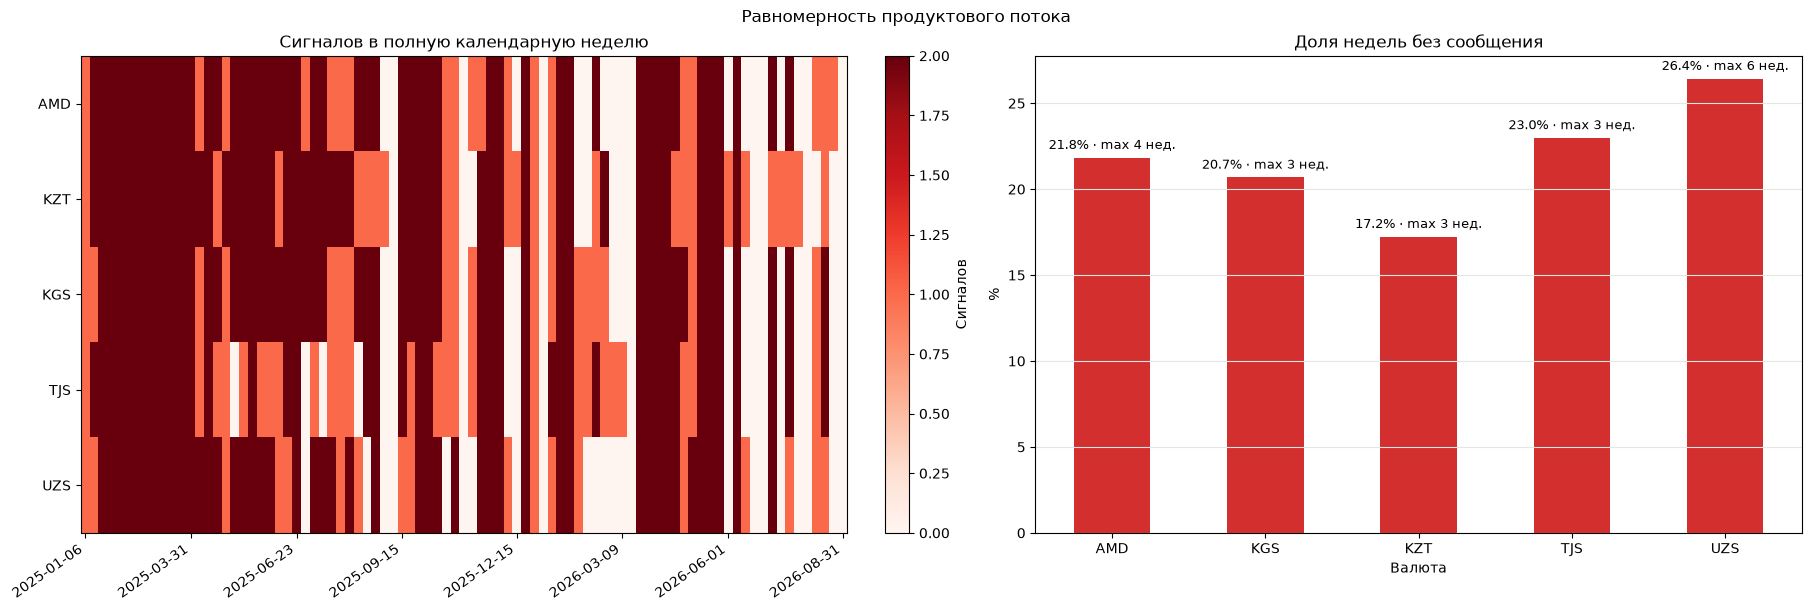

In [5]:
def longest_zero_run(values):
    longest = current = 0
    for value in values:
        current = current + 1 if int(value) == 0 else 0
        longest = max(longest, current)
    return longest

events = result.final_signals.copy()
events['available_at'] = pd.to_datetime(events['available_at'])
audit_start = pd.Timestamp(result.temporal_plan.holdout_start)
audit_end = pd.Timestamp(result.temporal_plan.data_end).normalize()
first_monday = audit_start.normalize() + pd.offsets.Week(weekday=0)
if audit_start.dayofweek == 0:
    first_monday = audit_start.normalize()
week_starts = pd.date_range(first_monday, audit_end, freq='W-MON')
week_starts = week_starts[
    week_starts + pd.Timedelta(days=6) <= audit_end
]
grid = pd.MultiIndex.from_product(
    [CONFIG.currencies, week_starts],
    names=['currency', 'week_start'],
).to_frame(index=False)
events['week_start'] = (
    events['available_at'].dt.to_period('W-SUN').dt.start_time
)
counts = (
    events.groupby(['currency', 'week_start']).size()
    .rename('signals').reset_index()
)
weekly_flow = grid.merge(
    counts, on=['currency', 'week_start'], how='left'
)
weekly_flow['signals'] = weekly_flow['signals'].fillna(0).astype(int)
summary_rows = []
for currency, sample in weekly_flow.groupby('currency', sort=True):
    values = sample.sort_values('week_start')['signals']
    summary_rows.append({
        'currency': currency, 'complete_weeks': len(values),
        'empty_weeks': int(values.eq(0).sum()),
        'empty_week_share': float(values.eq(0).mean()),
        'weeks_with_1_signal': int(values.eq(1).sum()),
        'weeks_with_2_signals': int(values.eq(2).sum()),
        'mean_signals_per_week': float(values.mean()),
        'max_signals_in_calendar_week': int(values.max()),
        'longest_empty_streak_weeks': longest_zero_run(values),
    })
weekly_summary = pd.DataFrame(summary_rows)
weekly_summary.to_csv(OUTPUT_DIR / 'weekly_gap_summary.csv', index=False)
weekly_flow.to_csv(OUTPUT_DIR / 'weekly_counts.csv', index=False)
display(weekly_summary.round(3))

weekly_matrix = weekly_flow.pivot(
    index='currency', columns='week_start', values='signals'
).reindex(CONFIG.currencies)
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)
image = axes[0].imshow(
    weekly_matrix, aspect='auto', cmap='Reds', vmin=0, vmax=2
)
tick_positions = np.linspace(
    0, len(weekly_matrix.columns) - 1, 8
).astype(int)
axes[0].set_xticks(
    tick_positions,
    [weekly_matrix.columns[i].strftime('%Y-%m-%d') for i in tick_positions],
    rotation=35, ha='right',
)
axes[0].set_yticks(range(len(weekly_matrix)), weekly_matrix.index)
axes[0].set_title('Сигналов в полную календарную неделю')
fig.colorbar(image, ax=axes[0], label='Сигналов')
gap_plot = weekly_summary.set_index('currency')
gap_plot['empty_week_share'].mul(100).plot.bar(
    ax=axes[1], color='#d32f2f'
)
for position, value in enumerate(gap_plot['empty_week_share'].mul(100)):
    longest = int(gap_plot.iloc[position]['longest_empty_streak_weeks'])
    axes[1].text(
        position, value + 0.5, f'{value:.1f}% · max {longest} нед.',
        ha='center', fontsize=9,
    )
axes[1].set(
    title='Доля недель без сообщения', xlabel='Валюта', ylabel='%',
)
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', color='#e5e5e5')
fig.suptitle('Равномерность продуктового потока')
fig.savefig(OUTPUT_DIR / 'weekly_signal_gaps.png', dpi=180)
plt.show()

## 5. Автоматический итог

Нижняя bootstrap-граница отвечает на вопрос, выдерживает ли lift порог с учётом статистической неопределённости. OOT показывает переносимость между временными режимами. Пустые недели — отдельная продуктовая характеристика, а не дефект ML-метрики. После просмотра OOT менять параметры нельзя без нового закрытого holdout.

In [6]:
overall = bootstrap_summary.loc[
    bootstrap_summary['currency'].eq('ALL')
].iloc[0]
weakest_bootstrap = (
    bootstrap_summary.loc[bootstrap_summary['currency'].ne('ALL')]
    .sort_values('lift_ci_low').iloc[0]
)
weakest_oot = oot_summary.sort_values('min_currency_lift').iloc[0]
worst_gap = weekly_summary.sort_values(
    ['longest_empty_streak_weeks', 'empty_week_share'],
    ascending=False,
).iloc[0]

print(
    f"Bootstrap ALL: lift={overall['lift']:.2f}, "
    f"95% CI [{overall['lift_ci_low']:.2f}; "
    f"{overall['lift_ci_high']:.2f}], "
    f"BPS uplift={overall['mean_bps_uplift']:.1f}."
)
print(
    f"Самая осторожная валютная оценка: "
    f"{weakest_bootstrap['currency']}, нижняя граница "
    f"lift={weakest_bootstrap['lift_ci_low']:.2f}."
)
print(
    f"Самое слабое OOT-окно: {weakest_oot['oot_period']}, "
    f"минимальный lift валюты={weakest_oot['min_currency_lift']:.2f}."
)
print(
    f"Самая длинная пауза: {worst_gap['currency']} — "
    f"{int(worst_gap['longest_empty_streak_weeks'])} недель подряд; "
    f"пустых недель {worst_gap['empty_week_share']:.1%}."
)

audit_checks = pd.DataFrame([
    {
        'check': 'Bootstrap: нижняя граница lift ≥ 1.3 у каждой валюты',
        'passed': bool(
            bootstrap_summary.loc[
                bootstrap_summary['currency'].ne('ALL'), 'lift_ci_low'
            ].ge(1.3).all()
        ),
    },
    {
        'check': 'Bootstrap: нижняя граница BPS uplift > 0',
        'passed': bool(bootstrap_summary['bps_ci_low'].gt(0).all()),
    },
    {
        'check': 'OOT: lift ≥ 1.3 у каждой валюты во всех окнах',
        'passed': bool(oot_summary['all_currencies_lift_ge_1p3'].all()),
    },
    {
        'check': 'OOT: ни одно тестовое окно не использовано для настройки',
        'passed': bool(oot_summary['leakage_free'].all()),
    },
])
display(audit_checks)

Bootstrap ALL: lift=2.31, 95% CI [1.91; 2.78], BPS uplift=37.2.
Самая осторожная валютная оценка: KZT, нижняя граница lift=1.38.
Самое слабое OOT-окно: 2025, минимальный lift валюты=1.47.
Самая длинная пауза: UZS — 6 недель подряд; пустых недель 26.4%.


,check,passed
0,Bootstrap: нижняя граница lift ≥ 1.3 у каждой ...,True
1,Bootstrap: нижняя граница BPS uplift > 0,True
2,OOT: lift ≥ 1.3 у каждой валюты во всех окнах,True
3,OOT: ни одно тестовое окно не использовано для...,True
